# 02 — Removing unpredictable spikes

Big one-day (or few-day) peaks usually come from news: someone dies, wins a match, appears on TV.
We can't foresee them from past traffic, so:

- **In the inputs**, a spike makes the model think the page's normal level is higher than it is.
- **In the training targets**, a spike teaches the model to expect peaks it has no way to predict.

So we **clip spikes** before training, in both inputs and targets. Scoring still uses the **real, unclipped values**:
the test is honest, we only change what the model learns from.

Model: the best one from notebook 01, **GRU + missing-data mask + seasonal inputs**, with one extra input channel
that marks days that were clipped.

Comparison:
1. Baseline (median of the last 49 days)
2. GRU + mask + seasonal, raw data
3. GRU + mask + seasonal, spikes clipped
4. Same as 3, plus **noise pages** (mostly empty, with one huge spike) left out of training

## 1. Setup and data

In [1]:
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
device = "mps" if torch.backends.mps.is_available() else "cpu"
device

'mps'

In [2]:
df = pd.read_csv("data/wiki_web_flow.csv", index_col="Page")
df.columns = pd.to_datetime(df.columns)
dates = df.columns

raw = df.values                                               # real values (with NaN), used for scoring
observed = df.notna().values                                  # True = real value
values = np.log1p(df.fillna(0).values).astype(np.float32)     # model input: log scale, NaN -> 0
first_valid = observed.argmax(axis=1)                         # first real day of each page
n_pages, n_days = values.shape
print(f"{n_pages:,} pages x {n_days} days, {(~observed).mean():.1%} missing")

145,063 pages x 803 days, 6.0% missing


## 2. Split, metric, baseline

Same as notebook 01: the last 60 days are the test set, the 60 before are validation.

In [3]:
HORIZON, LOOKBACK, YEAR = 60, 180, 364
test_start = n_days - HORIZON
val_start = test_start - HORIZON
print("validation:", dates[val_start].date(), "->", dates[test_start - 1].date())
print("test:      ", dates[test_start].date(), "->", dates[-1].date())


def smape(y, yhat):
    """SMAPE in %, skipping days where the true value is NaN."""
    denom = (np.abs(y) + np.abs(yhat)) / 2
    diff = np.where(denom == 0, 0, np.abs(y - yhat) / np.where(denom == 0, 1, denom))
    return 100 * np.nanmean(np.where(np.isnan(y), np.nan, diff))


def baseline(start, window=49):
    hist = raw[:, start - window:start]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")              # pages with no data in the window
        med = np.nan_to_num(np.nanmedian(hist, axis=1))
    return np.repeat(med[:, None], HORIZON, axis=1)


results = {"baseline (median 49d)": {
    "val": smape(raw[:, val_start:test_start], baseline(val_start)),
    "test": smape(raw[:, test_start:], baseline(test_start)),
}}
pd.DataFrame(results).T.round(2)

validation: 2017-05-14 -> 2017-07-12
test:       2017-07-13 -> 2017-09-10


,val,test
baseline (median 49d),40.25,40.13


## 3. Finding spikes

A day is a **spike** when its views are far above the page's recent normal level:

- **normal** = median of the **previous** 28 days (median, so earlier spikes don't raise it)
- spike if views > `SPIKE_FACTOR` × normal **and** views > normal + `SPIKE_MIN_EXTRA`
  (the second rule ignores tiny pages going from 1 to 4 views)
- a spike is **clipped** to `SPIKE_FACTOR` × normal: the day stays "busy", just not extreme

Only previous days are used to decide, so cleaning never looks into the future
(important: otherwise the validation/test inputs would contain information from after the cutoff).

A side effect: when a page **permanently** becomes more popular, the first days after the jump get clipped
until the 28-day median catches up (about two weeks).

In [4]:
SPIKE_WINDOW = 28        # normal level = median of the previous 28 days
SPIKE_FACTOR = 3         # spike if more than 3x normal...
SPIKE_MIN_EXTRA = 20     # ...and at least 20 views above normal

log_raw = np.log1p(raw)                                               # NaN stays NaN
normal = np.expm1(
    pd.DataFrame(log_raw.T).rolling(SPIKE_WINDOW, min_periods=7).median().shift(1).values.T
)                                                                     # shift(1): previous days only
del log_raw
cap = SPIKE_FACTOR * (normal + 1) - 1                                 # 3x normal, on the log1p scale

with np.errstate(invalid="ignore"):
    is_spike = observed & (raw > cap) & (raw > normal + SPIKE_MIN_EXTRA)
    values_clean = np.where(is_spike, np.log1p(cap), values).astype(np.float32)

removed = np.where(is_spike, raw - np.expm1(values_clean), 0)
print(f"spike days: {is_spike.sum():,} ({is_spike.sum() / observed.sum():.2%} of real days)")
print(f"pages with at least one spike: {is_spike.any(axis=1).sum():,} ({is_spike.any(axis=1).mean():.1%})")
print(f"views removed: {np.nansum(removed) / np.nansum(raw):.1%} of all views")

spike days: 3,585,370 (3.28% of real days)
pages with at least one spike: 135,757 (93.6%)
views removed: 8.6% of all views


### How the threshold changes things

Lower factor = more days clipped. 3 is a middle ground; change `SPIKE_FACTOR` above and re-run to try others.

In [5]:
rows = []
with np.errstate(invalid="ignore"):
    for f in [2, 3, 5, 10]:
        sp = observed & (raw > f * (normal + 1) - 1) & (raw > normal + SPIKE_MIN_EXTRA)
        rows.append({
            "factor": f,
            "spike days %": 100 * sp.sum() / observed.sum(),
            "pages with spikes %": 100 * sp.any(axis=1).mean(),
        })
pd.DataFrame(rows).set_index("factor").round(2)

,spike days %,pages with spikes %
factor,,
2,6.06,96.08
3,3.28,93.58
5,1.67,87.87
10,0.74,73.57


### Examples: the pages that lost the most views

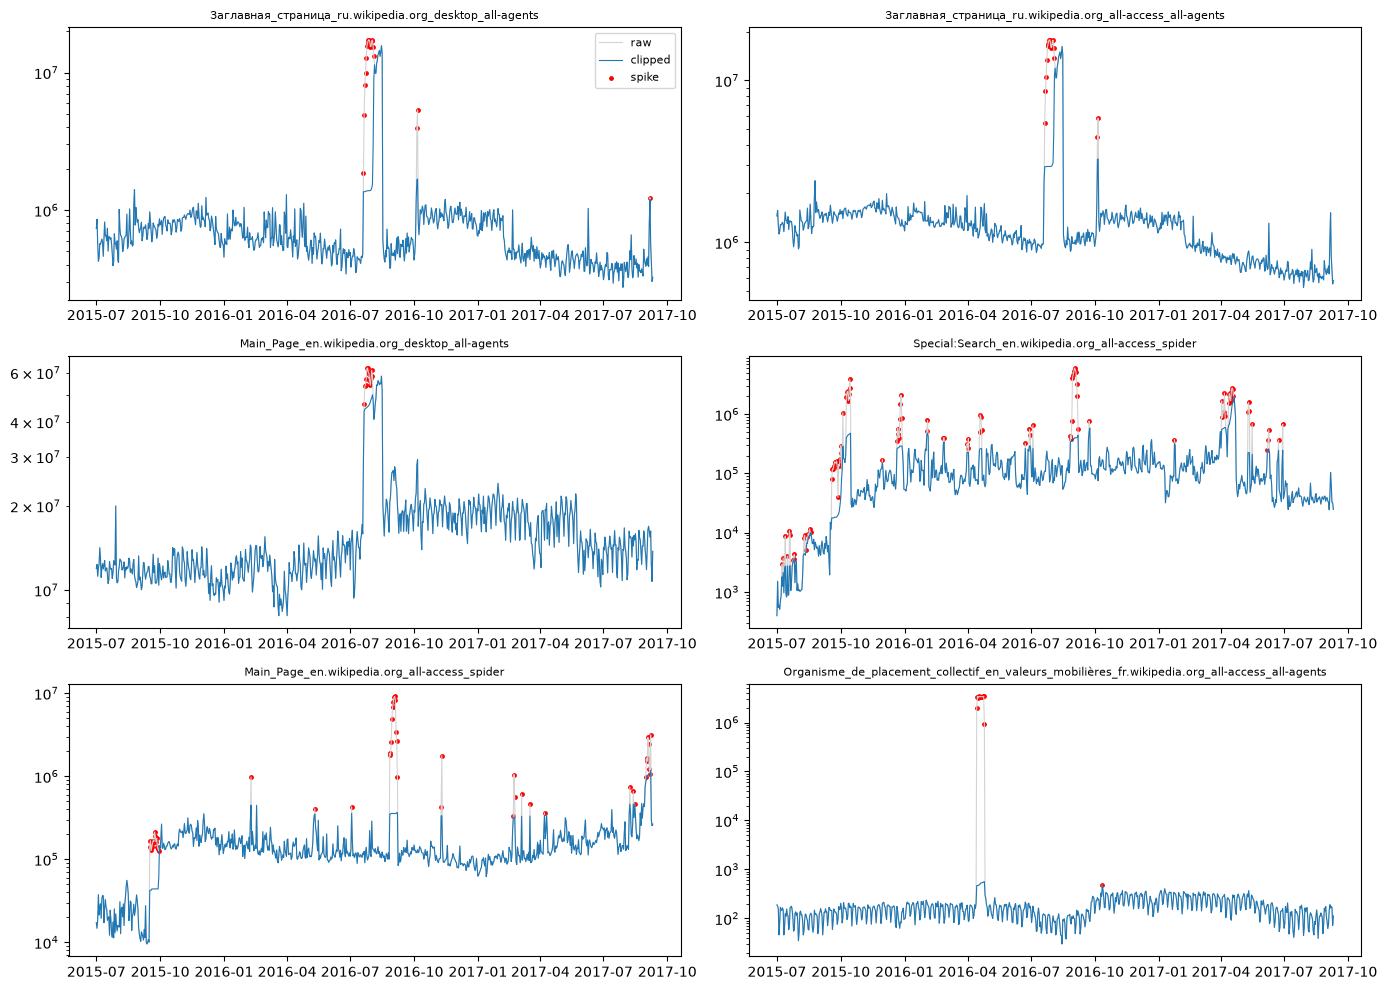

In [6]:
top = np.argsort(np.nansum(removed, axis=1))[-6:][::-1]

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
for ax, r in zip(axes.flat, top):
    ax.plot(dates, raw[r], color="lightgrey", lw=0.8, label="raw")
    ax.plot(dates, np.where(observed[r], np.expm1(values_clean[r]), np.nan), lw=0.8, label="clipped")
    ax.scatter(dates[is_spike[r]], raw[r, is_spike[r]], color="red", s=6, label="spike")
    ax.set_yscale("log")
    ax.set_title(df.index[r], fontsize=8)
axes.flat[0].legend(fontsize=8)
fig.tight_layout()
plt.show()

del normal, cap, removed      # free memory

## 3b. Pages that are mostly empty with one huge spike

Pattern: `NaN NaN NaN NaN HUGE SPIKE NaN NaN NaN NaN`. These pages are almost never visited, except once
when something happened. There is no regular behaviour to learn from them, so they are **left out of training**.

A page is a **noise page** when both:
- **low coverage**: fewer than `MIN_COVERAGE` of its days (counted from its first real value) have data
- **concentrated**: its `TOP_DAYS` biggest days hold more than `MIN_TOP_SHARE` of all its views

Only the **training period** (before `val_start`) is used to decide, so the choice doesn't peek at validation/test.

They are still **forecast and scored**: results are shown for all pages and for the kept pages only.

In [7]:
MIN_COVERAGE = 0.5       # less than half of the days have data...
TOP_DAYS = 5
MIN_TOP_SHARE = 0.5      # ...and the 5 biggest days hold more than half of all views

train_raw = raw[:, :val_start]
days_since_first = val_start - first_valid                                   # <= 0: page starts later
with np.errstate(invalid="ignore", divide="ignore"):
    coverage = observed[:, :val_start].sum(axis=1) / days_since_first
filled = np.nan_to_num(train_raw)
total_views = filled.sum(axis=1)
top_views = np.partition(filled, -TOP_DAYS, axis=1)[:, -TOP_DAYS:].sum(axis=1)
top_share = np.divide(top_views, total_views, out=np.zeros(n_pages), where=total_views > 0)

is_noise_page = (days_since_first > 0) & (coverage < MIN_COVERAGE) & (top_share > MIN_TOP_SHARE)
del train_raw, filled

print(f"noise pages: {is_noise_page.sum():,} ({is_noise_page.mean():.1%} of pages)")
print(f"their share of all views: {np.nansum(raw[is_noise_page]) / np.nansum(raw):.2%}")

noise pages: 1,469 (1.0% of pages)
their share of all views: 0.04%


/var/folders/sz/3_np9r_91db6_dhc9819tkwh0000gn/T/ipykernel_17806/3617830716.py:10: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/sz/3_np9r_91db6_dhc9819tkwh0000gn/T/ipykernel_17806/3617830716.py:10: UserWarning: Glyph 21029 (\N{CJK UNIFIED IDEOGRAPH-5225}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/sz/3_np9r_91db6_dhc9819tkwh0000gn/T/ipykernel_17806/3617830716.py:10: UserWarning: Glyph 12501 (\N{KATAKANA LETTER HU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/sz/3_np9r_91db6_dhc9819tkwh0000gn/T/ipykernel_17806/3617830716.py:10: UserWarning: Glyph 12451 (\N{KATAKANA LETTER SMALL I}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/sz/3_np9r_91db6_dhc9819tkwh0000gn/T/ipykernel_17806/3617830716.py:10: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/sz/3_n

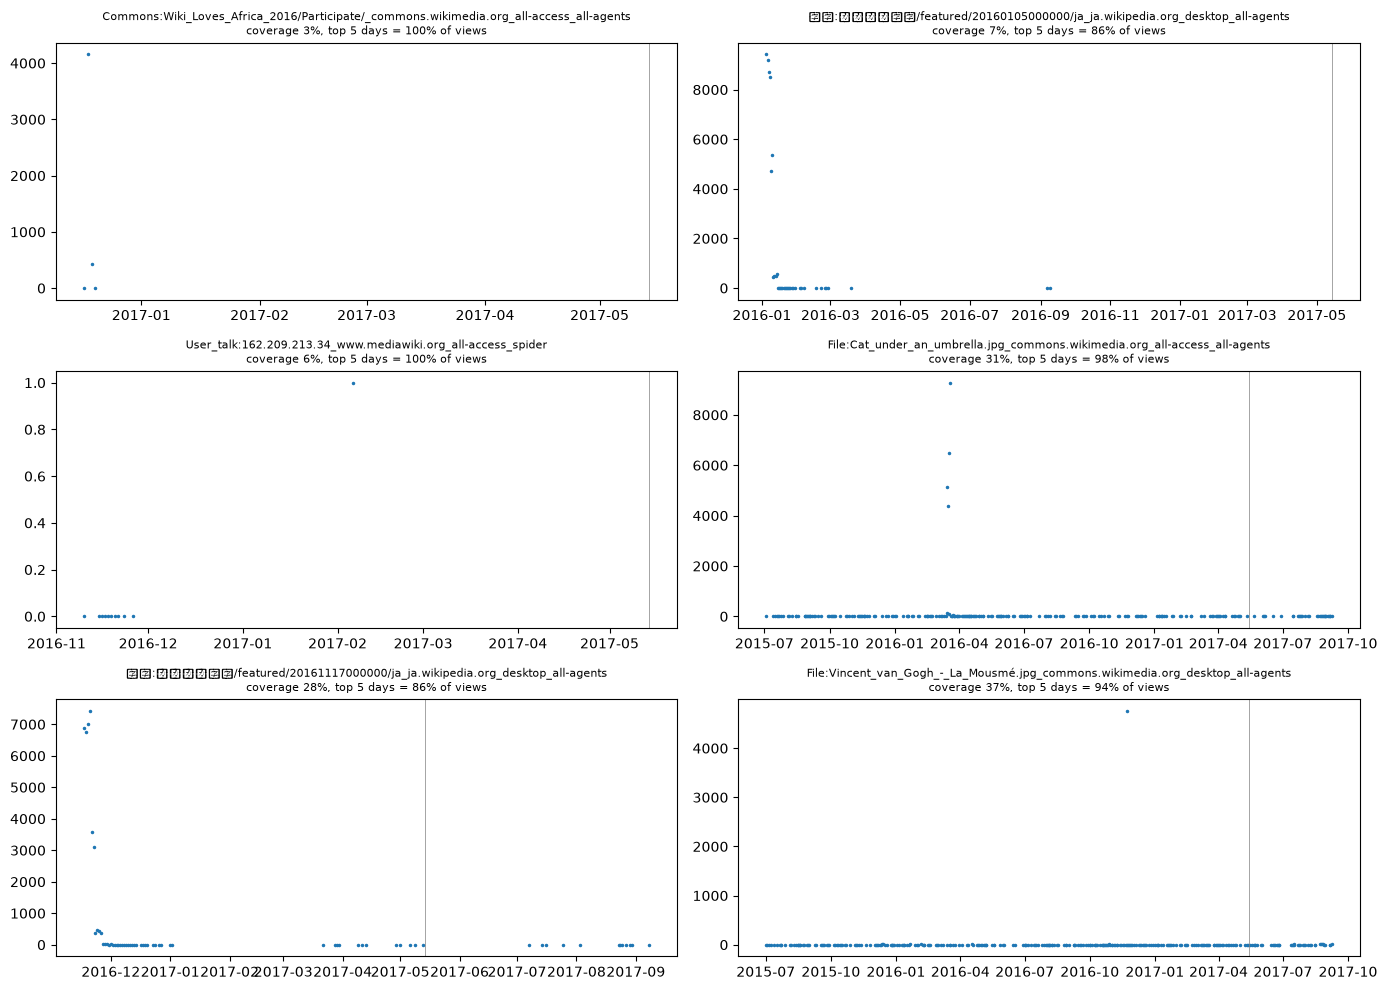

In [8]:
# what noise pages look like (dots: the lines would break at every NaN)
noise_rows = np.where(is_noise_page)[0]
sample = np.random.choice(noise_rows, min(6, len(noise_rows)), replace=False)

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
for ax, r in zip(axes.flat, sample):
    ax.plot(dates, raw[r], ".", ms=3)
    ax.axvline(dates[val_start], color="grey", lw=0.5)
    ax.set_title(f"{df.index[r]}\ncoverage {coverage[r]:.0%}, top {TOP_DAYS} days = {top_share[r]:.0%} of views", fontsize=8)
fig.tight_layout()
plt.show()

## 4. Model: GRU + mask + seasonal + spike flag

Same as notebook 01 section 9, plus one input channel: **1 if the day was clipped**.
The model then knows "something unusual happened here" without being dragged around by the size of the peak.

Inputs per day: views, observed mask, spike flag, 6 calendar values (weekly / monthly / yearly `sin`/`cos`).
Plus the same 60 days one year earlier, given to the output layer.

All functions take the views array (`vals`) and spike flags (`flags`) as arguments,
so the same code trains on raw or on clipped data.

In [9]:
def circular(x, period):
    angle = 2 * np.pi * np.asarray(x) / np.asarray(period)
    return np.sin(angle), np.cos(angle)

calendar = np.stack([
    *circular(dates.dayofweek, 7),                          # weekly
    *circular(dates.day - 1, dates.days_in_month),          # monthly
    *circular(dates.dayofyear - 1, 365.25),                 # yearly
], axis=1).astype(np.float32)
N_CAL = calendar.shape[1]


def make_inputs(vals, flags, rows, end):
    """seq: (..., LOOKBACK, 3 + N_CAL)   year_ago: (..., 2 * HORIZON)"""
    v = vals[rows, end - LOOKBACK:end]
    m = observed[rows, end - LOOKBACK:end].astype(np.float32)
    s = flags[rows, end - LOOKBACK:end].astype(np.float32)
    cal = np.broadcast_to(calendar[end - LOOKBACK:end], v.shape + (N_CAL,))
    seq = np.concatenate([v[..., None], m[..., None], s[..., None], cal], axis=-1)

    yv = vals[rows, end - YEAR:end - YEAR + HORIZON]
    ym = observed[rows, end - YEAR:end - YEAR + HORIZON].astype(np.float32)
    return seq.astype(np.float32), np.concatenate([yv, ym], axis=-1).astype(np.float32)


class WindowDataset(Dataset):
    """Random 180 -> 60 day windows before `last_day`; targets come from `vals` (raw or clipped).
    `exclude`: optional boolean array of pages to leave out of training."""
    def __init__(self, vals, flags, last_day, exclude=None):
        lo = np.maximum(first_valid + LOOKBACK, YEAR)
        keep = lo <= last_day - HORIZON
        print(f"too little history: {(~keep).sum():,} pages dropped")
        if exclude is not None:
            print(f"excluded: {(keep & exclude).sum():,} more pages dropped")
            keep &= ~exclude
        print(f"training pages: {keep.sum():,}")
        self.rows, self.lo = np.arange(n_pages)[keep], lo[keep]
        self.vals, self.flags, self.last_day = vals, flags, last_day

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, i):
        r = self.rows[i]
        end = np.random.randint(self.lo[i], self.last_day - HORIZON + 1)
        seq, year_ago = make_inputs(self.vals, self.flags, r, end)
        y = self.vals[r, end:end + HORIZON]
        y_obs = observed[r, end:end + HORIZON].copy()
        return seq, year_ago, y, y_obs


class SeasonalGRU(nn.Module):
    def __init__(self, hidden=128, layers=2):
        super().__init__()
        self.gru = nn.GRU(3 + N_CAL, hidden, layers, batch_first=True, dropout=0.1)
        self.head = nn.Sequential(
            nn.Linear(hidden + 2 * HORIZON, hidden),
            nn.ReLU(),
            nn.Linear(hidden, HORIZON),
        )

    def forward(self, seq, year_ago):
        v, w = seq[..., 0], seq[..., 1]
        level = (v * w).sum(1, keepdim=True) / w.sum(1, keepdim=True).clamp(min=1)
        z = ((v - level) * w).unsqueeze(-1)
        out, _ = self.gru(torch.cat([z, seq[..., 1:]], dim=-1))     # mask, spike flag, calendar unchanged

        yv, ym = year_ago[:, :HORIZON], year_ago[:, HORIZON:]
        year_z = (yv - level) * ym
        return self.head(torch.cat([out[:, -1], year_z, ym], dim=-1)) + level

## 5. Training

In [10]:
@torch.no_grad()
def predict(model, vals, flags, end, batch=4096):
    """Forecast the 60 days after `end` for every page, in views."""
    model.eval()
    preds = []
    for start in range(0, n_pages, batch):
        seq, year_ago = make_inputs(vals, flags, slice(start, start + batch), end)
        out = model(torch.from_numpy(seq).to(device), torch.from_numpy(year_ago).to(device))
        preds.append(out.cpu().numpy())
    return np.expm1(np.concatenate(preds)).clip(0).round()


def train(vals, flags, epochs, lr=1e-3, lr_schedule=True, patience=None, exclude=None):
    """Train on `vals` (raw or clipped). Validation is always scored on the REAL values, all pages."""
    torch.manual_seed(0)
    np.random.seed(0)
    model = SeasonalGRU().to(device)
    loader = DataLoader(WindowDataset(vals, flags, val_start, exclude), batch_size=256, shuffle=True)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=1) if lr_schedule else None
    best_val, best_state, bad_epochs = np.inf, None, 0

    for epoch in range(epochs):
        model.train()
        total = 0
        for seq, year_ago, y, y_obs in loader:
            seq, year_ago, y = seq.to(device), year_ago.to(device), y.to(device)
            w = y_obs.to(device).float()                                    # ignore NaN targets
            loss = ((model(seq, year_ago) - y).abs() * w).sum() / w.sum().clamp(min=1)
            opt.zero_grad()
            loss.backward()
            opt.step()
            total += loss.item() * len(y)

        val = smape(raw[:, val_start:test_start], predict(model, vals, flags, val_start))
        if scheduler:
            scheduler.step(val)
        print(f"epoch {epoch + 1}: train loss {total / len(loader.dataset):.3f}  val SMAPE {val:.2f}"
              f"  lr {opt.param_groups[0]['lr']:.0e}")
        if val < best_val:
            best_val, bad_epochs = val, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad_epochs += 1
            if patience is not None and bad_epochs >= patience:
                print(f"early stop: no improvement for {patience} epochs")
                break

    model.load_state_dict(best_state)
    return model, best_val

All runs use the same settings and seed, so each one differs from the previous by one change only.
Each epoch takes ~30 s; `EPOCHS = 10` → about 5 min per model.

In [11]:
EPOCHS = 10
no_flags = np.zeros_like(is_spike)          # the raw model gets an all-zero spike channel
test_preds = {"baseline (median 49d)": baseline(test_start)}

### 5a. Raw data

In [ ]:
model_raw, val = train(values, no_flags, EPOCHS)
pred_raw = predict(model_raw, values, no_flags, test_start)
results["GRU seasonal, raw"] = {"val": val, "test": smape(raw[:, test_start:], pred_raw)}
test_preds["GRU seasonal, raw"] = pred_raw

too little history: 2,825 pages dropped
training pages: 142,238
epoch 1: train loss 0.434  val SMAPE 36.58  lr 1e-03
epoch 2: train loss 0.417  val SMAPE 35.96  lr 1e-03


### 5b. Spikes clipped

In [ ]:
model_clean, val = train(values_clean, is_spike, EPOCHS)
pred_clean = predict(model_clean, values_clean, is_spike, test_start)
results["GRU seasonal, spikes clipped"] = {"val": val, "test": smape(raw[:, test_start:], pred_clean)}
test_preds["GRU seasonal, spikes clipped"] = pred_clean

### 5c. Spikes clipped + noise pages left out of training

In [ ]:
model_trim, val = train(values_clean, is_spike, EPOCHS, exclude=is_noise_page)
pred_trim = predict(model_trim, values_clean, is_spike, test_start)
results["GRU seasonal, clipped + no noise pages"] = {"val": val, "test": smape(raw[:, test_start:], pred_trim)}
test_preds["GRU seasonal, clipped + no noise pages"] = pred_trim

## 6. Results

- **val / test**: all pages (noise pages included, they still get a forecast)
- **test, kept pages**: noise pages removed from scoring too, the score on the pages we actually model

In [ ]:
kept = ~is_noise_page
table = pd.DataFrame(results).T
table["test, kept pages"] = [smape(raw[kept, test_start:], test_preds[name][kept]) for name in table.index]
table.round(2)

### Where does the error come from?

Split the test days into **spike days** (by the same rule as above) and **normal days**.
We expect both models to do badly on spike days (they're unpredictable); clipping should help on normal days.

In [ ]:
y_test = raw[:, test_start:]
spike_days = is_spike[:, test_start:]
breakdown = {}
for name, pred in test_preds.items():
    breakdown[name] = {
        "all days": smape(y_test, pred),
        "normal days": smape(np.where(spike_days, np.nan, y_test), pred),
        "spike days": smape(np.where(spike_days, y_test, np.nan), pred),
    }
print(f"spike days in the test period: {spike_days.sum():,} ({spike_days.sum() / observed[:, test_start:].sum():.2%})")
pd.DataFrame(breakdown).T.round(2)

## 7. Forecasts on pages with a spike in the test period

In [ ]:
spiky_in_test = np.where(spike_days.any(axis=1))[0]
sample = np.random.choice(spiky_in_test, 6, replace=False)

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
for ax, r in zip(axes.flat, sample):
    ax.plot(dates[test_start - 120:], raw[r, test_start - 120:], color="black", lw=0.8, label="actual")
    ax.plot(dates[test_start:], pred_raw[r], label="GRU raw")
    ax.plot(dates[test_start:], pred_clean[r], label="GRU clipped")
    ax.plot(dates[test_start:], pred_trim[r], label="GRU clipped + no noise pages")
    ax.scatter(dates[test_start:][spike_days[r]], y_test[r, spike_days[r]], color="red", s=8, label="spike")
    ax.axvline(dates[test_start], color="grey", lw=0.5)
    ax.set_title(df.index[r], fontsize=8)
axes.flat[0].legend(fontsize=8)
fig.tight_layout()
plt.show()

## Next ideas

- Try other `SPIKE_FACTOR` values (2, 5) and compare validation SMAPE
- Clip inputs only, keep raw targets (or the reverse) to see which part helps
- Also clip sudden **drops** (e.g. outages), not only peaks
- Try other `MIN_COVERAGE` / `MIN_TOP_SHARE` values for the noise pages
- For noise pages, a plain 0 or median forecast may beat the GRU: compare on `is_noise_page` only